In [1]:
import warnings

warnings.simplefilter("ignore", FutureWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig4"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(8,8),
                                   vector_friendly=True
                             )


# Load

In [3]:
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()
adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

 

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


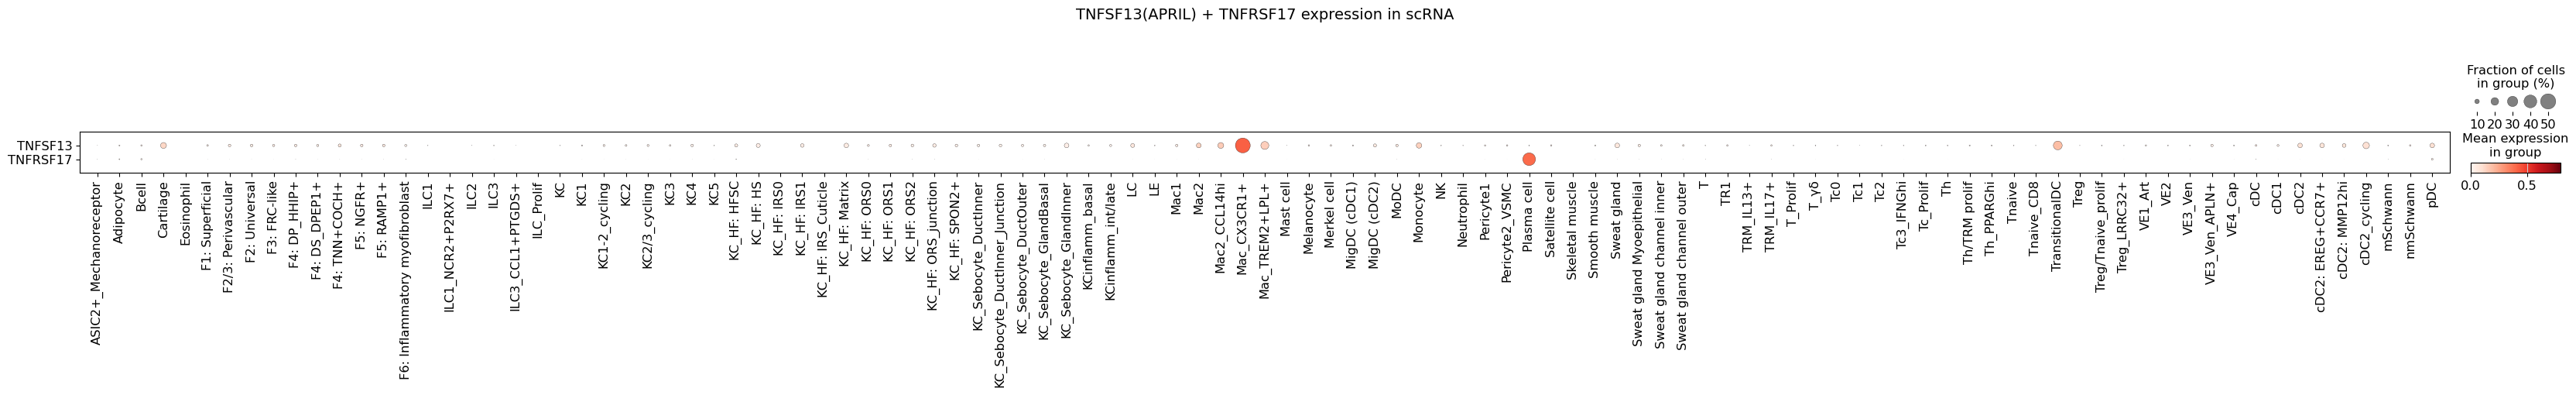

In [6]:
sc.pl.dotplot(
    adata,
     [ 'TNFSF13', 
                    'TNFRSF17'
                    ],
    groupby="lvl5_annotation",
    vmax=0.8,
    swap_axes=True,
       # dot_max=0.3,
    save='plotTNFRSF17_TNFSF13_scrna.pdf',
        title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [9]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape



(2825, 32732)

In [10]:
sc.pp.normalize_total(adata_plasma, target_sum=1e4)
sc.pp.log1p(adata_plasma)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [11]:
adata_plasma_l = adata_plasma[(adata_plasma.obs["Site_status"]=="Week 12")|
                              (adata_plasma.obs["Site_status"]=="Lesional")|
                              (adata_plasma.obs["Site_status"].str.startswith("3D"))|
                               (adata_plasma.obs["Site_status"]=="Psoriasis_replicate_Lesional")
                              
                               ]
adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)

{x:x for x in adata_plasma_l.obs["t"].unique()}

RENAME = {'Plasma cell_ADLesional': 'Plasma cell_AD_Lesional',
 'Bcell_ADLesional': 'Bcell_AD_Lesional',
 'Bcell_ADWeek 12': 'Bcell_AD_Week12',
 'Plasma cell_ADWeek 12': 'Plasma cell_AD_Week12',
 'Plasma cell_PsoriasisLesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_PsoriasisLesional': 'Bcell_Psoriasis_Lesional',
 'Bcell_nanPsoriasis_replicate_Lesional': 'Bcell_Psoriasis_Lesional',
 'Plasma cell_nanPsoriasis_replicate_Lesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_3d_Lesional_baseline3D_Lesional_baseline': 'Bcell_AD_Lesional',
 'Plasma cell_3d_Lesional_baseline3D_Lesional_baseline': 'Plasma cell_AD_Lesional',
 'Bcell_3d_Week123D_Week12': 'Bcell_AD_Week12',
 'Plasma cell_3d_Week123D_Week12': 'Plasma cell_AD_Week12',
 'Plasma cell_3d_Lesional_baseline3D_Week12': 'Plasma cell_AD_Week12',
 'Bcell_3d_Lesional_baseline3D_Week12': 'Bcell_AD_Week12'}
adata_plasma_l.obs["t2"]=adata_plasma_l.obs["t"].map(RENAME)
adata_plasma_l.obs["t2"].value_counts()
# exclude = ['Bcell_nanPsoriasis_replicate_Lesional',
           
#           ]
# adata_plasma_l=adata_plasma_l[~adata_plasma_l.obs["t"].isin(exclude)]

/tmp/ipykernel_1533506/1676745639.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)


t2
Plasma cell_AD_Lesional           151
Bcell_Psoriasis_Lesional           83
Bcell_AD_Lesional                  75
Plasma cell_Psoriasis_Lesional     65
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


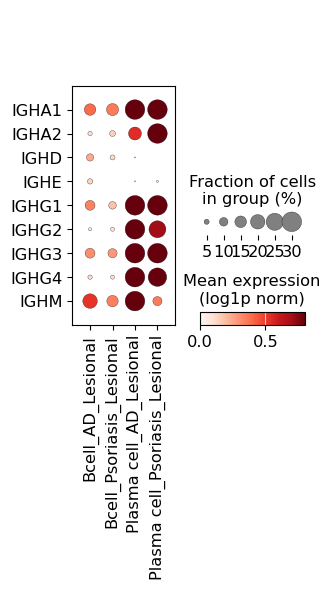

In [12]:
heavy_genes = ["IGHA1", "IGHA2", "IGHD","IGHE", "IGHG1", "IGHG2", "IGHG3", "IGHG4",  "IGHM", ]
sc.pl.dotplot(
    adata_plasma_l,
     heavy_genes,
    groupby="t2",
    vmax=0.8,
    swap_axes=True,
     dot_max=0.3,

    save='plotIGS_SCRNA.pdf',
    colorbar_title='Mean expression\n(log1p norm)'

)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


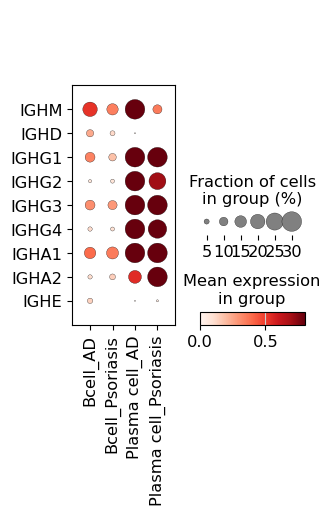

In [13]:

# adata_plasma.obs["t"] = adata_plasma.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma.obs["Patient_status"].astype(str)
# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="t",
#     vmax=0.8,
#     swap_axes=True,
#      dot_max=0.3,

#     save='plotIGS.pdf',

# )


In [14]:
# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="Patient_status",
#     vmax=2,
#     swap_axes=True,
#        dot_max=0.3,

#     save='plotIGS.pdf',
#     title="Ig expression in scRNA plasma cells by patient status"

# )


In [15]:
# adata_plasma=adata[adata.obs["lvl5_annotation"]=="Bcell"]
# adata_plasma.shape

# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="Patient_status",
#     vmax=2,
#     swap_axes=True,
#        dot_max=0.3,

#     save='plotIGS_Bcell.pdf',
#     title="Ig expression in scRNA B-cells by patient status"

# )


In [16]:
cell_types = [
    "cDC1",
    "Mac2",
    "T",
    "Pericyte1",
    "Ve3_Ven",
    "Plasma cell",
    #"Bcell",
    "F3: FRC-like",
    "VE1_Art",'VE3_Ven',
    "VE4_Cap",
   # 'mSchwann',
    #'nmSchwann',
    "F2/3: Perivascular"
]

ORDER = [


 'Plasma cell',
 'Sweat gland Myoepithelial',
         'Sweat gland',
          'Sweat gland channel outer',
 'Sweat gland channel inner',
 'VE1_Art','VE3_Ven',
 'VE4_Cap',
    'Mac2',
 'T',

 'cDC1',
'F3: FRC-like', "F2/3: Perivascular", 'Pericyte1', 
    
    # 'mSchwann',
   # 'nmSchwann',
]

adata=adata[(adata.obs["lvl5_annotation"].isin(cell_types))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))
           ].copy()


In [17]:
import gc
gc.collect()

24447

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


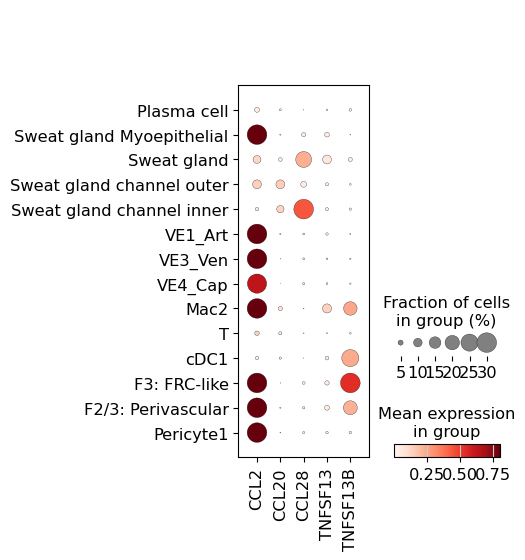

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


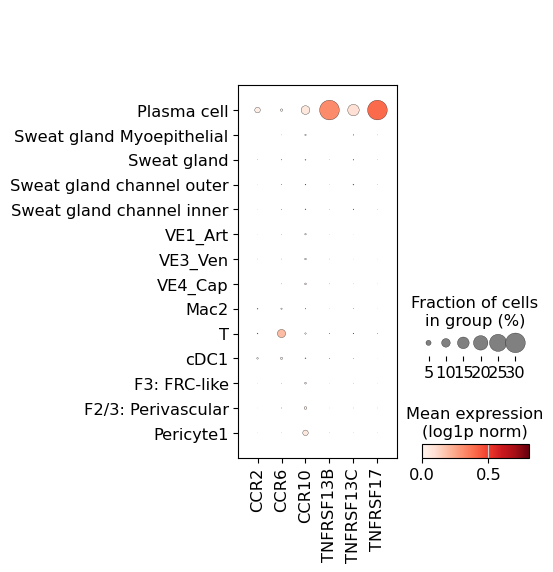

In [18]:
sc.pl.dotplot(
    adata,
     ["CCL2", "CCL20", "CCL28", 'TNFSF13', 'TNFSF13B'],
    groupby="lvl5_annotation",
    vmax=0.8,
    categories_order=ORDER,
        dot_max=0.3,

    save='4h_plasma_Cell_dotplot1.pdf'
)

sc.pl.dotplot(
    adata,
       ["CCR2", "CCR6", "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17'],
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    save='4h_plasma_Cell_dotplot2.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


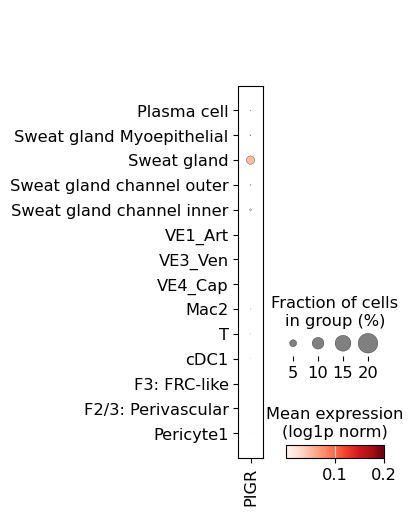

In [24]:
sc.pl.dotplot(
    adata,
     ["PIGR",],
    groupby="lvl5_annotation",
    vmax=0.2,
    categories_order=ORDER,
        dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp_plasma_Cell_PIGRscrna.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


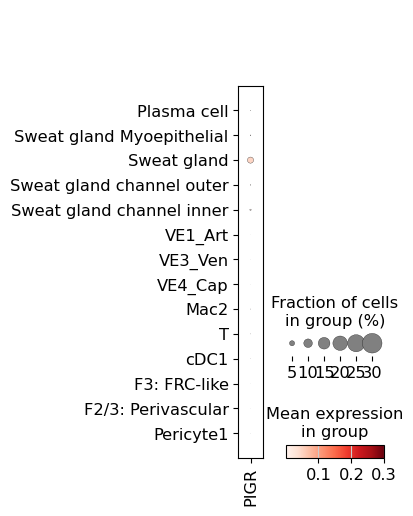

In [23]:
sc.pl.dotplot(
    adata,
     ["PIGR",],
    groupby="lvl5_annotation",
    vmax=0.3,
    categories_order=ORDER,
        dot_max=0.3,

    save='supp_plasma_Cell_PIGRscrna0.3.pdf'
)


# xenium validation (sFig 16b)

In [25]:
import scanpy as sc
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered')
import gc
gc.collect()
adata=adata[adata.obs["tech"]=="xenium"]

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST

 


In [26]:

# genes = adata.var.index.tolist()

# with open("/nfs/team298/ls34/xenium_genes.pkl", "wb") as f:
#     pickle.dump(genes, f)

In [27]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [28]:
import pandas as pd

subset = adata.obs[adata.obs["niche19"].str.startswith("Plasma")]
vc = subset["lvl5_annotation"].value_counts()
vc

lvl5_annotation
Plasma cell           371
Pericyte1              27
VE3_Ven                19
Mac2                   18
F3: FRC-like           18
                     ... 
KC_HF: ORS1             0
KC_HF: ORS0             0
KC_HF: Matrix           0
KC_HF: IRS_Cuticle      0
pDC                     0
Name: count, Length: 100, dtype: int64

In [29]:
vc_filtered = vc[vc >= 10]



adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))
           ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))
           |
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))].copy()
adata.obs["lvl5_annotation"].value_counts()


lvl5_annotation
Sweat gland                  25854
Sweat gland channel outer    21529
Sweat gland channel inner    11036
Sweat gland Myoepithelial     6208
Plasma cell                    371
Pericyte1                       27
VE3_Ven                         19
F3: FRC-like                    18
Mac2                            18
VE1_Art                         16
T                               14
F2/3: Perivascular              13
cDC1                            12
VE4_Cap                         10
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


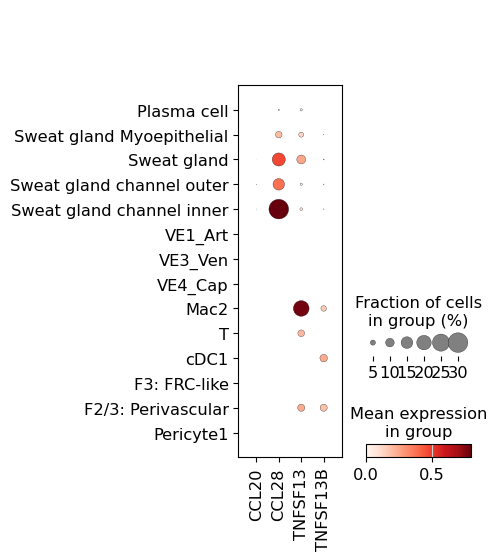

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


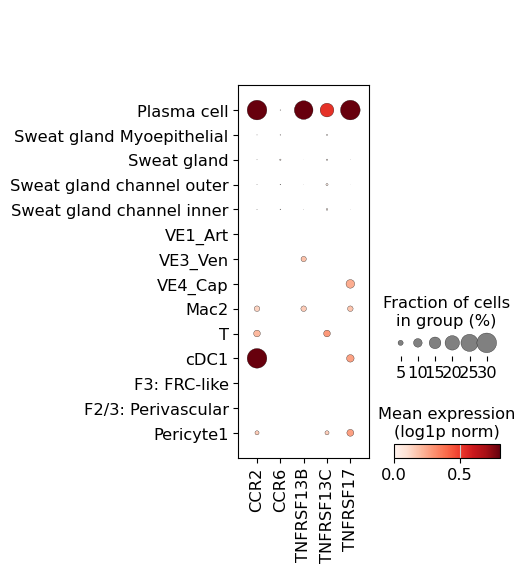

In [30]:
sc.pl.dotplot(
    adata,
     remove_markers(["CCL2", "CCL20", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="lvl5_annotation",
    vmax=0.8,
    categories_order=ORDER,
        dot_max=0.3,

    save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

sc.pl.dotplot(
    adata,
       remove_markers(["CCR2", "CCR6", "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [31]:

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))|
#            (adata.obs["lvl5_annotation"].str.startswith("Sweat"))
#            ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))
           |
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))].copy()
adata.obs["lvl5_annotation"].value_counts()


lvl5_annotation
Sweat gland                  25854
Sweat gland channel outer    21529
Sweat gland channel inner    11036
Sweat gland Myoepithelial     6208
Plasma cell                    371
Pericyte1                       27
VE3_Ven                         19
F3: FRC-like                    18
Mac2                            18
VE1_Art                         16
T                               14
F2/3: Perivascular              13
cDC1                            12
VE4_Cap                         10
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


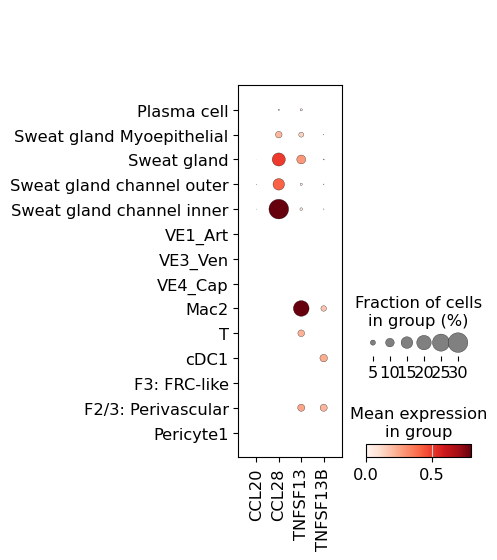

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


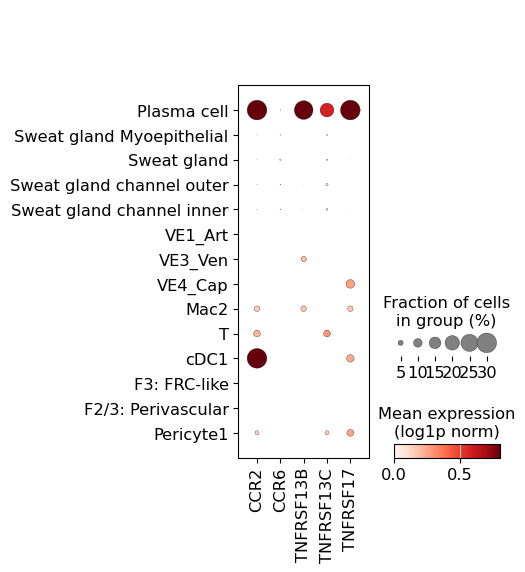

In [32]:
sc.pl.dotplot(
    adata,
     remove_markers(["CCL2", "CCL20", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="lvl5_annotation",
    vmax=0.8,
    categories_order=ORDER,
        dot_max=0.3,

    save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)

sc.pl.dotplot(
    adata,
       remove_markers(["CCR2", "CCR6", "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp16_plasma_Cell_dotplot2_XENIUM_allcells.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [33]:
# sc.pl.dotplot(
#     adata,
#      remove_markers(["PIGR",]),
#     groupby="lvl5_annotation",
#     vmax=0.8,
#     categories_order=ORDER,
#         dot_max=0.6,

#     save='4k_plasma_Cell_PIGRxenium.pdf'
# )


In [34]:
# requested plot


In [35]:
# sc.settings.set_figure_params(dpi_save=600, facecolor="white", frameon=False, figsize=(17,17))

# NICHE =  'Plasma_cell_rich'
# MIN_NUMBER_CELLS=10

# CORE_PAPER =["BK23_Week 12",
#                                        "BK27_Week 12",
#                                       'BK27_Lesional Baseline',
#                                          'BK24_Lesional Baseline']
# for i, tissue_section_id in enumerate(CORE_PAPER):
#     print(tissue_section_id)
#    # print(i, "/", len(adata_5k.obs["info_id6"].unique()))
#     adata_i =  adata[adata.obs["info_id6"]==tissue_section_id]


#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#        # library_id="spatial",
#       #  shape=None,
#         color=["TNFSF13"],
#         spot_size=10,
#         vmax=1,
#                 edgecolor="black",
#         linewidth=0.02,
#                 legend_fontsize=12,
#       #  title=x,
#         legend_loc=None,
#            cmap="Reds",
#         save=f"plotAPRILspatial_{i}.pdf"
#     )
#     #     if i>1:
#     #         break

 
 
       

In [36]:
# for x in [ 'BK39_Lesional Baseline',  'BK22_Lesional Baseline',
#           'Lesional_CE3-SKI-24-FO-1-S22-A1',
#         #  'Lesional_Baseline_resolved_CE3-SKI-24-FO-1-S22_replicate',
#           # 'Lesional_CE3-SKI-24-FO-1-S22_replicate',
#            'Lesional_CE4-SKI-27-FO-4-S22-A2',
#       #'Lesional_CE4-SKI-27-FO-4-S22_replicate',

#          ]:
#     adata_i=adata[adata.obs["info_id6"]==x]

   
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#        # library_id="spatial",
#       #  shape=None,
#         color=["TNFSF13"],
#         spot_size=10,
#         vmax=1,
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#       #  title=x,
#         legend_loc=None,
#            cmap="Reds"
#     )
#     #     if i>1:
#     #         break

 
 


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


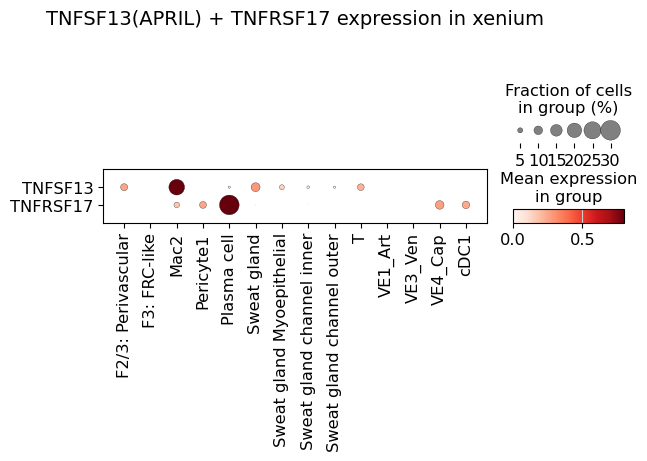

In [37]:
sc.pl.dotplot(
    adata,
     remove_markers([ 'TNFSF13', 
                    'TNFRSF17'
                    ]),
    groupby="lvl5_annotation",
    vmax=0.8,
        dot_max=0.3,
    save='plotTNFRSF17_TNFSF13_xenium.pdf',
    swap_axes=True,
    title="TNFSF13(APRIL) + TNFRSF17 expression in xenium"

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [38]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape

(371, 4993)

In [39]:
adata_plasma.obs["niche19"].value_counts()

niche19
Plasma_cell_rich    371
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


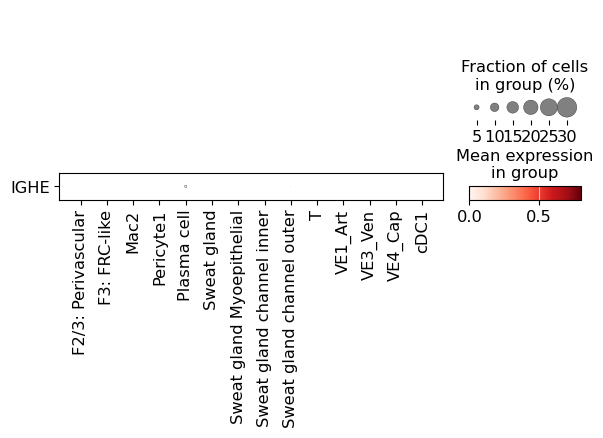

In [40]:
sc.pl.dotplot(
    adata,
     remove_markers([ #'TNFSF13', 
                    #'TNFRSF17', 
                     "IGHE",
                    ]),
    groupby="lvl5_annotation",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [41]:
niche_counts = adata_plasma.obs["niche19"].value_counts()
valid = niche_counts[niche_counts >= 10].index
adata_plasma = adata_plasma[adata_plasma.obs["niche19"].isin(valid)].copy()
adata_plasma.obs["niche19"] = adata_plasma.obs["niche19"].cat.remove_unused_categories()

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


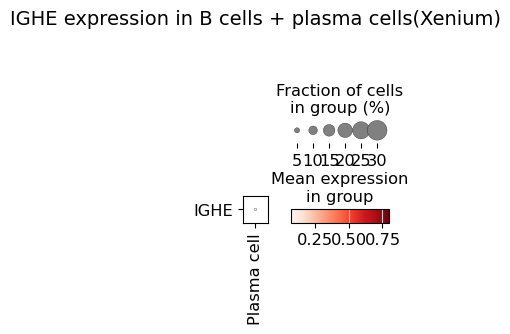

In [42]:
sc.pl.dotplot(
    adata_plasma,#[adata_plasma.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="lvl5_annotation",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
    title="IGHE expression in B cells + plasma cells(Xenium)"

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


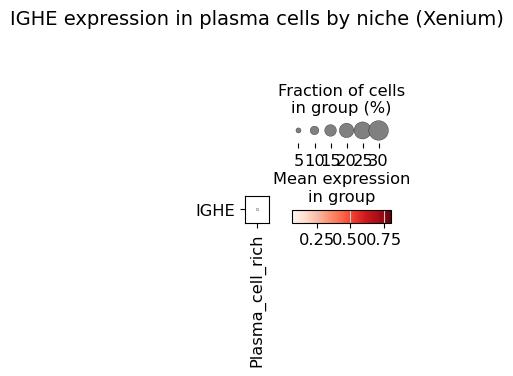

In [43]:
sc.pl.dotplot(
    adata_plasma[adata_plasma.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
        save="IGs_inplasmacell_byniche.pdf",
    title="IGHE expression in plasma cells by niche (Xenium)"


  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [44]:
sc.pl.dotplot(
    adata,
     remove_markers([ 'TNFSF13', 
                    'TNFRSF17', 
                     "IGHE",
                    ]),
    groupby="",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


ValueError: groupby has to be a valid observation. Given , is not in observations: ['sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary',

In [ ]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape


In [ ]:
adata_plasma.obs["lvl5_annotation"].value_counts()

In [ ]:
adata_plasma.obs["Site_status"].value_counts()

In [ ]:
adata_plasma_l = adata_plasma[(adata_plasma.obs["Site_status"]=="Week 12")|
                              (adata_plasma.obs["Site_status"]=="Lesional")|
                              (adata_plasma.obs["Site_status"].str.startswith("3D"))|
                               (adata_plasma.obs["Site_status"]=="Psoriasis_replicate_Lesional")
                              
                               ]


In [ ]:
adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)

{x:x for x in adata_plasma_l.obs["t"].unique()}



In [ ]:
adata_plasma_l[adata_plasma_l.obs["t"]== 'Plasma cell_3d_Week123D_Week12'].obs.info_id6.value_counts()

In [ ]:
RENAME = {'Plasma cell_ADLesional': 'Plasma cell_AD_Lesional',
 'Bcell_ADLesional': 'Bcell_AD_Lesional',
 'Bcell_ADWeek 12': 'Bcell_AD_Week12',
 'Plasma cell_ADWeek 12': 'Plasma cell_AD_Week12',
 'Plasma cell_PsoriasisLesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_PsoriasisLesional': 'Bcell_Psoriasis_Lesional',
 'Bcell_nanPsoriasis_replicate_Lesional': 'Bcell_Psoriasis_Lesional',
 'Plasma cell_nanPsoriasis_replicate_Lesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_3d_Lesional_baseline3D_Lesional_baseline': 'Bcell_AD_Lesional',
 'Plasma cell_3d_Lesional_baseline3D_Lesional_baseline': 'Plasma cell_AD_Lesional',
 'Bcell_3d_Week123D_Week12': 'Bcell_AD_Week12',
 'Plasma cell_3d_Week123D_Week12': 'Plasma cell_AD_Week12',
 'Plasma cell_3d_Lesional_baseline3D_Week12': 'Plasma cell_AD_Week12',
 'Bcell_3d_Lesional_baseline3D_Week12': 'Bcell_AD_Week12'}
adata_plasma_l.obs["t2"]=adata_plasma_l.obs["t"].map(RENAME)
adata_plasma_l.obs["t2"].value_counts()
# exclude = ['Bcell_nanPsoriasis_replicate_Lesional',
           
#           ]
# adata_plasma_l=adata_plasma_l[~adata_plasma_l.obs["t"].isin(exclude)]

In [ ]:
heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
sc.pl.dotplot(
    adata_plasma_l,
     remove_markers(heavy_genes),
    groupby="t2",
    vmax=0.8,
    swap_axes=True,
     dot_max=0.3,

    save='plotIGS_xenium.pdf',
    colorbar_title='Mean expression\n(log1p norm)'

)


In [ ]:
adata_plasma_l.obs.niche19.value_counts()

In [ ]:
niche_counts = adata_plasma_l.obs["niche19"].value_counts()
valid = niche_counts[niche_counts >= 10].index
adata_plasma_l = adata_plasma_l[adata_plasma_l.obs["niche19"].isin(valid)].copy()
adata_plasma_l.obs["niche19"] = adata_plasma_l.obs["niche19"].cat.remove_unused_categories()

In [ ]:
sc.pl.dotplot(
    adata_plasma_l[adata_plasma_l.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
       # save="IGs_inplasmacell_byniche.pdf",
    title="IGHE expression in plasma cells by niche (Xenium)",
    save="IGs_by_niche.pdf"

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
sc.pl.dotplot(
    adata_plasma_l[adata_plasma_l.obs["lvl5_annotation"]=="Bcell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
     save="IGs_inBcell_byniche.pdf",
    title="IGHE expression in B cells by niche (Xenium)"


  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


### 